<a href="https://colab.research.google.com/github/whateveri/models/blob/custom_dataset/custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn

device= "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


# Download Data 'Pizza steak sushi'

In [2]:
import requests
import zipfile
from pathlib import Path
import os

print(os.getcwd())
data_path=os.path.join(os.getcwd(),"sanple_data","food_data")
image_path=os.path.join(data_path,"pizza_steak_sushi")

URL_="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

if os.path.exists(image_path):
    print(f'dir {image_path} already exist')

else:
    print(f'Did not find dir {image_path}, creating one....')
    os.makedirs(image_path,exist_ok=True)

    with open(os.path.join(image_path,"pizza_steak_sushi.zip"),mode='wb') as f:
        request=requests.get(URL_)
        print(f'Downloading 3_food data...')
        f.write(request.content)

    with zipfile.ZipFile(os.path.join(image_path,"pizza_steak_sushi.zip"),mode='r') as zipf:
        print(f'Extracting Zip file...')
        zipf.extractall(image_path)






/content
Did not find dir /content/sanple_data/food_data/pizza_steak_sushi, creating one....
Extracting Zip file...


# Data Preperation
1.   Go through the dataset and get the data structure




In [3]:
from os import walk

def walk_through_data(dir_path):
    for sub_paths, dir_names, filenames in walk(dir_path):
        print(f'There are {len(dir_names)} directories and {len(filenames)} images in {sub_paths}')
walk_through_data(image_path)

There are 2 directories and 1 images in /content/sanple_data/food_data/pizza_steak_sushi
There are 3 directories and 0 images in /content/sanple_data/food_data/pizza_steak_sushi/train
There are 0 directories and 78 images in /content/sanple_data/food_data/pizza_steak_sushi/train/pizza
There are 0 directories and 72 images in /content/sanple_data/food_data/pizza_steak_sushi/train/sushi
There are 0 directories and 75 images in /content/sanple_data/food_data/pizza_steak_sushi/train/steak
There are 3 directories and 0 images in /content/sanple_data/food_data/pizza_steak_sushi/test
There are 0 directories and 25 images in /content/sanple_data/food_data/pizza_steak_sushi/test/pizza
There are 0 directories and 31 images in /content/sanple_data/food_data/pizza_steak_sushi/test/sushi
There are 0 directories and 19 images in /content/sanple_data/food_data/pizza_steak_sushi/test/steak


In [73]:
train_path=os.path.join(image_path,"train")
test_path=os.path.join(image_path,"test")
train_pth=Path(train_path)
test_pth=Path(test_path)
image_path=Path(image_path)
data_path=Path(data_path)
print(train_pth,test_pth)


/content/sanple_data/food_data/pizza_steak_sushi/train /content/sanple_data/food_data/pizza_steak_sushi/test


2.   Visualize a image



Random image path:/content/sanple_data/food_data/pizza_steak_sushi/test/steak/100274.jpg
Random image class:steak
Image Height: 384
Image Width: 512


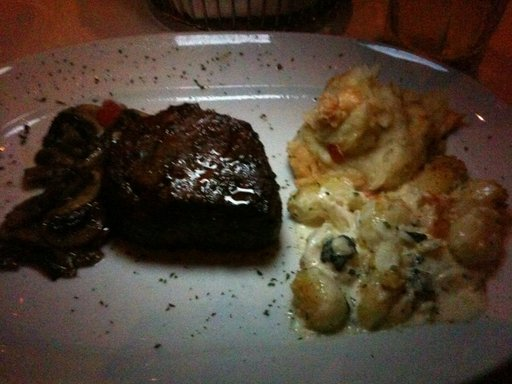

In [5]:
import random
from PIL import Image

#set seed
random.seed(56)

#get all image paths
image_path_list=list(image_path.glob("*/*/*.jpg"))

#get random imagr path
random_image_path=random.choice(image_path_list)
#Get the image class from its parent path
random_image_class=random_image_path.parent.stem

#open Image
img=Image.open(random_image_path)

print(f'Random image path:{random_image_path}')
print(f'Random image class:{random_image_class}')
print(f'Image Height: {img.height}')
print(f'Image Width: {img.width}')
img


(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

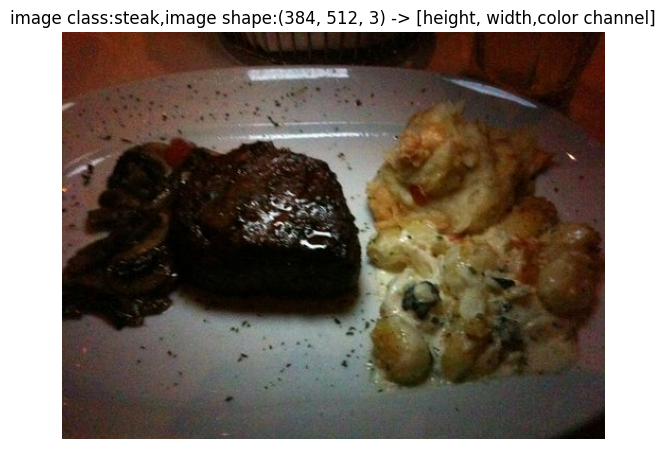

In [6]:
#use plt do the sam thing as above
import numpy as np
import matplotlib.pyplot as plt

img_as_array=np.asarray(img)

plt.figure(figsize=(7,10))
plt.imshow(img_as_array)
plt.title(f'image class:{random_image_class},image shape:{img_as_array.shape} -> [height, width,color channel]')
plt.axis(False)


# Data Trasforming

In [7]:
from torchvision import datasets, transforms

#transform with transforms

#define transform sequence
image_transfrom=transforms.Compose([
    #resize
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()]
)



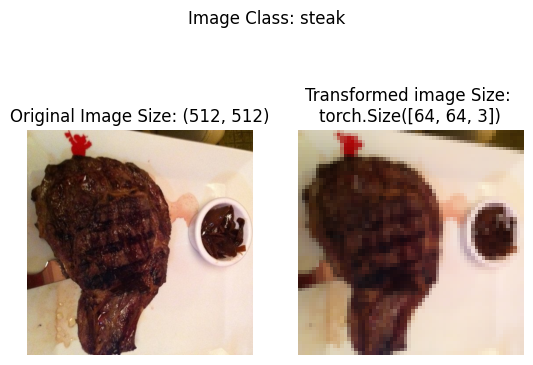

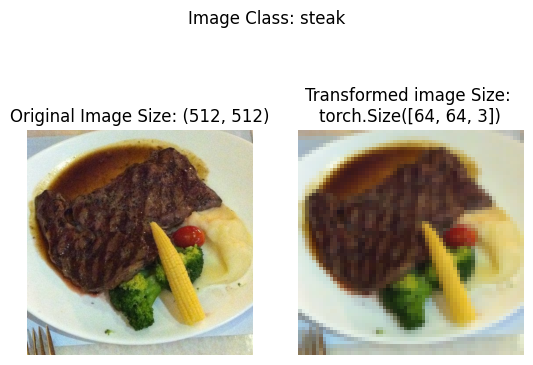

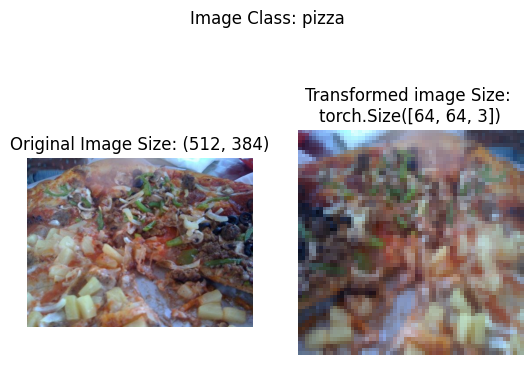

In [8]:
def plot_transformed_images(image_paths,transform, n=3,seed=98):
    random.seed(seed)
    random_image_paths=random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f'Original Image Size: {f.size}')
            ax[0].axis(False)
            # pytorch default (C,H,W)-> matplotlib default (H,W,C)
            transformed_image=transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed image Size: \n{transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f'Image Class: {image_path.parent.stem}')

plot_transformed_images(image_paths=image_path_list,transform=image_transfrom)


# Data Loading


### optioin 1 :use torchvision.datasets.ImageFolder




In [9]:
from torchvision import datasets

train_data=datasets.ImageFolder(root=train_pth,transform=image_transfrom,target_transform=None) #target_transform: transform on labels

test_data=datasets.ImageFolder(root=test_pth,transform=image_transfrom)

print(f'Train data: \n{train_data}\n Test data:\n{test_data}')



Train data: 
Dataset ImageFolder
    Number of datapoints: 225
    Root location: /content/sanple_data/food_data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
 Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: /content/sanple_data/food_data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [10]:
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [11]:
class_dicts=train_data.class_to_idx
class_dicts

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [12]:
print(f'Train data length:{len(train_data)} \n Test data length:{len(test_data)}' )

Train data length:225 
 Test data length:75


In [13]:
img,label=train_data[2][0],train_data[2][1]
print(f'image tensor:\n {img}')
print(f'image shape:\n{img.shape}')
print(f'image type: \n{img.dtype}')
print(f'image label: \n{label}')
print(f'image label datatype: \n{type(label)}')

image tensor:
 tensor([[[0.0392, 0.0392, 0.0431,  ..., 0.2275, 0.2314, 0.2314],
         [0.0392, 0.0392, 0.0392,  ..., 0.2196, 0.2235, 0.2196],
         [0.0392, 0.0392, 0.0392,  ..., 0.2078, 0.2118, 0.2118],
         ...,
         [0.8118, 0.8078, 0.7961,  ..., 0.5373, 0.4863, 0.4039],
         [0.5176, 0.6157, 0.6392,  ..., 0.2902, 0.2000, 0.1608],
         [0.2863, 0.3333, 0.3686,  ..., 0.1216, 0.0902, 0.0784]],

        [[0.0353, 0.0353, 0.0392,  ..., 0.1922, 0.1922, 0.1922],
         [0.0353, 0.0353, 0.0353,  ..., 0.1804, 0.1843, 0.1843],
         [0.0353, 0.0353, 0.0353,  ..., 0.1765, 0.1725, 0.1765],
         ...,
         [0.5804, 0.5373, 0.5294,  ..., 0.4588, 0.4000, 0.3176],
         [0.2941, 0.3765, 0.3882,  ..., 0.2196, 0.1373, 0.1098],
         [0.1529, 0.1608, 0.1686,  ..., 0.0863, 0.0706, 0.0588]],

        [[0.0157, 0.0157, 0.0196,  ..., 0.1961, 0.2000, 0.2078],
         [0.0157, 0.0157, 0.0157,  ..., 0.1843, 0.1843, 0.1882],
         [0.0157, 0.0157, 0.0196,  ..., 0.1

Original shape:
 torch.Size([3, 64, 64])
Permuted shape:
 torch.Size([64, 64, 3])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

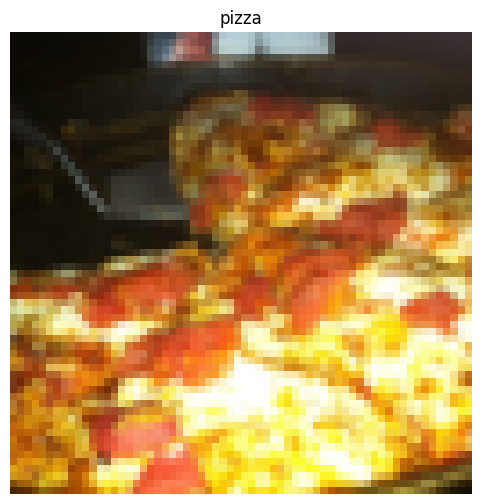

In [14]:
#use matplotlib plot the image

permuted_img=img.permute(1,2,0)

print(f'Original shape:\n {img.shape}')
print(f'Permuted shape:\n {permuted_img.shape}')

plt.figure(figsize=(10,6))
plt.imshow(permuted_img)
plt.title(class_names[label])
plt.axis('off')

In [15]:
from torch.utils.data import DataLoader
# load into DataLoader to make it iterable
train_dataloader=DataLoader(dataset=train_data,batch_size=1,num_workers=1,shuffle=True)
test_dataloader=DataLoader(dataset=test_data,batch_size=14,num_workers=1,shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fda03260e50>,
 <torch.utils.data.dataloader.DataLoader at 0x7fda126c9990>)

In [16]:
img,label=next(iter(train_dataloader))
print(f'Image shape:{img.shape} ->(batch_size, color_channels, height,weight)')
print(f'Label shape: {label.shape}')

Image shape:torch.Size([1, 3, 64, 64]) ->(batch_size, color_channels, height,weight)
Label shape: torch.Size([1])




### option 2.   with a custom dataset
replicate `torchvision.datasets.ImageFolder()` by subclassing `torch.utils.data.Dataset`



In [17]:

from typing import Tuple,Dict,List


In [18]:
def find_classes(directory: str) -> Tuple[List[str],Dict[str,int]]:
    classes=sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f'Could not find any classes in {directory}')

    class_to_idx={cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

find_classes(train_pth)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [19]:
from torch.utils.data import Dataset
import pathlib

class ImageFolderCustom(Dataset):

    def __init__(self,targ_dir:str,transform=None) -> None:
        #get all image paths
        self.paths=list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform=transform
        self.classes,self.class_to_idx=find_classes(targ_dir)

    def load_image(self,idx:int) ->Image.Image:
        image_path=self.paths[idx]
        return Image.open(image_path)

    def __len__(self)->int:
        return len(self.paths)

    def __getitem__(self, index) -> Tuple[torch.tensor,int]:
        #return a sample of the data (data,label)
        img=self.load_image(index)
        img_class=self.paths[index].parent.name
        class_idx=self.class_to_idx[img_class]

        #transform if necessary
        if self.transform:
            return self.transform(img),class_idx
        else:
            return img,class_idx





In [20]:
#create new transforms for new ImageFolderCustom

train_transforms=transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms=transforms.Compose([
    transforms.Resize(size=(128,128)),

    transforms.ToTensor()
])

In [21]:
# test ImageFolderCustom
train_data_custom=ImageFolderCustom(train_pth,transform=train_transforms)

test_data_custom=ImageFolderCustom(test_pth,transform=test_transforms)

train_data_custom,test_data_custom


(<__main__.ImageFolderCustom at 0x7fda03150fd0>,
 <__main__.ImageFolderCustom at 0x7fda03150bd0>)

In [22]:
len(train_data_custom),len(test_data_custom)

(225, 75)

In [23]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [24]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [25]:
# plot random images to test

def display_random_images(dataset:Dataset,
                          classes:List[str]=None,
                          n:int=10,
                          display_shape:bool=True,
                          seed:int=None):
    if n>10:
        n=10
        display_shape=False
        print(f'For display purpose, n shoulnd not larger than 10,setting n to 10 and removing display shape' )

    if seed:
        random.seed(seed)

    random_sample_idx=random.sample(range(len(dataset)),k=n)

    img=plt.figure(figsize=(16,8))

    for i, sample_idx in enumerate(random_sample_idx):
        sample_img,sample_label=dataset[sample_idx][0],dataset[sample_idx][1]

        premuted_sample_img=sample_img.permute(1,2,0) #(C,H,W)->(H,W,C)

        plt.subplot(1,n,i+1)
        plt.imshow(premuted_sample_img)
        plt.axis("off")
        if classes:
            title=f'class: {classes[sample_label]}'
            if display_shape:
                title+=f'\nshape:{premuted_sample_img.shape}'
        plt.title(title)



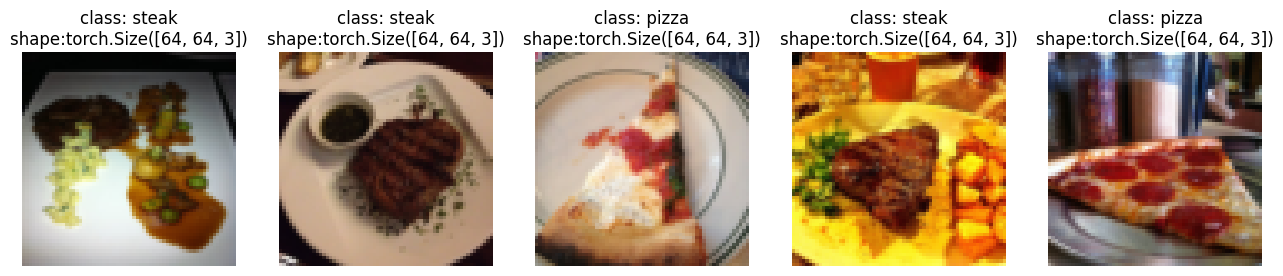

In [26]:
display_random_images(train_data,n=5,classes=class_names,seed=None)


For display purpose, n shoulnd not larger than 10,setting n to 10 and removing display shape


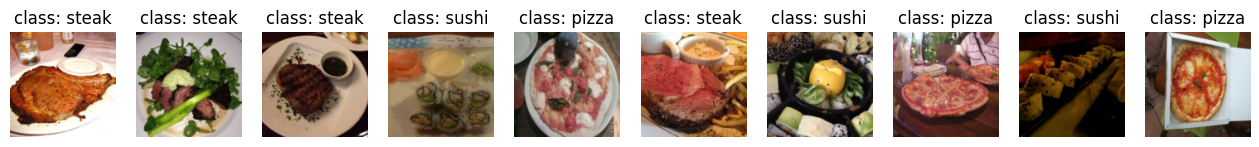

In [27]:
display_random_images(train_data_custom,n=12,classes=class_names,seed=None)

In [28]:
#load the custom data

train_dataloder_custom=DataLoader(dataset=train_data_custom,batch_size=1,num_workers=1,shuffle=True)

test_dataloder_custom=DataLoader(dataset=test_data_custom,batch_size=1,num_workers=1,shuffle=False)

train_dataloder_custom, test_dataloder_custom


(<torch.utils.data.dataloader.DataLoader at 0x7fda02f55cd0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fda02a1a310>)

In [29]:
img_custom,label_custom= next(iter(train_dataloder_custom))
print(f'Train custom img shape:\n {img_custom.shape}')
print(f'Train custom label shape:\n {label_custom.shape}')


Train custom img shape:
 torch.Size([1, 3, 128, 128])
Train custom label shape:
 torch.Size([1])


# Data Augmentation

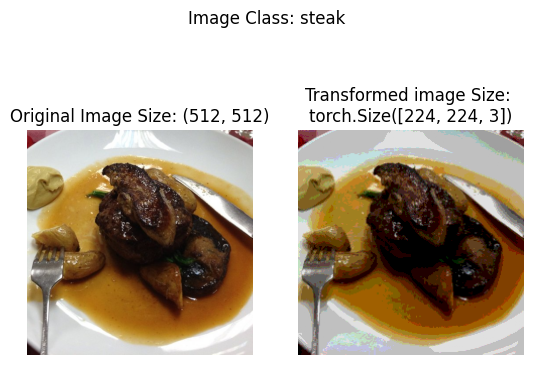

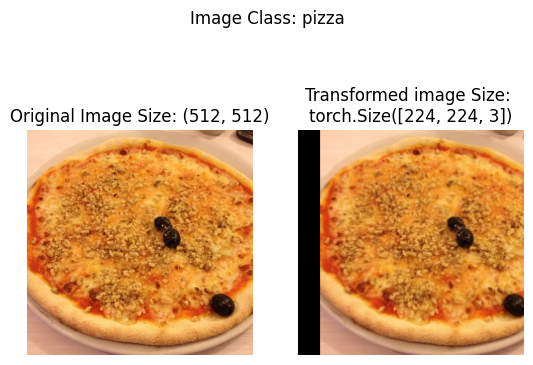

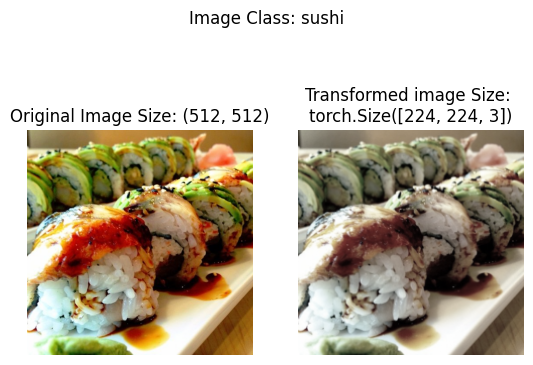

In [30]:
train_aug_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()

])

test_aug_tranform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

plot_transformed_images(image_path_list,train_aug_transform,n=3,seed=None)


# Model0: TinyVGG (a Transform ) without data augmentation

## creat simple transform and load data

In [31]:
from torchvision import transforms

simple_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])



In [32]:
from torchvision import datasets

train_dataset_simple=datasets.ImageFolder(root=train_pth,transform=simple_transform,target_transform=None)

test_dataset_simple=datasets.ImageFolder(root=test_pth,transform=simple_transform,target_transform=None)

import os
from torch.utils.data import DataLoader

BATCH_SIZE=32
WOKER_NUM=os.cpu_count()

train_dataloader=DataLoader(dataset=train_dataset_simple,batch_size=BATCH_SIZE,num_workers=WOKER_NUM,shuffle=True)

test_dataloader=DataLoader(dataset=test_dataset_simple,batch_size=BATCH_SIZE,num_workers=WOKER_NUM,shuffle=False)

train_dataloader,test_dataloader



(<torch.utils.data.dataloader.DataLoader at 0x7fda02d8d8d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fda02d53890>)

# Build TinyVGG model

In [44]:
class TinyVGG(nn.Module):

    def __init__(self, input_features:int, hidden_features:int, output_features:int) -> None:
        super().__init__()
        #input (3,64,64)
        self.block1=nn.Sequential(
            nn.Conv2d(in_channels=input_features,
                      out_channels=hidden_features,
                      kernel_size=3,
                      stride=1,
                      padding=1),   #(hidden,64,64)
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_features,
                      out_channels=hidden_features,
                      kernel_size=3,
                      stride=1,
                      padding=1),  #(hidden,64,64)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)  #(hidden,32,32)
        )

        self.block2=nn.Sequential(
            nn.Conv2d(in_channels=hidden_features,
                      out_channels=hidden_features,
                      kernel_size=3,
                      stride=1,
                      padding=1),   #(hidden,32,32)
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_features,
                      out_channels=hidden_features,
                      kernel_size=3,
                      stride=1,
                      padding=1),   #(hidden,32,32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2) #(hidden,16,16)


        )

        self.classifier=nn.Sequential(
            nn.Flatten(),   #(hidden*16*16)
            nn.Linear(in_features=hidden_features*16*16,
                      out_features=output_features)

        )


    def forward(self,x:torch.Tensor):
        x=self.block1(x)
       # print(x.shape)
        x=self.block2(x)
       # print(x.shape)
        x=self.classifier(x)
       # print(x.shape)
        return x

torch.manual_seed(54)

model0=TinyVGG(input_features=3,hidden_features=10,output_features=len(train_dataset_simple.classes)).to(device)

model0


TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [35]:
#use summary to view the shape changes in model

try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary

In [36]:
summary(model0,input_size=[1,3,64,64])

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([1, 3])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

# Build Train and Evaluate steps and conbine into the train process


In [55]:
def train_step(model:nn.Module,
               dataloader:DataLoader,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer):
    model.train()

    train_loss,train_acc=0.0,0

    for batch,(X,y) in enumerate(dataloader):
        X,y= X.to(device),y.to(device)

        y_pred=model(X)

        loss=loss_fn(y_pred,y)

        train_loss+=loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class=torch.argmax(torch.softmax(y_pred,dim=1),dim=1)

        train_acc+= (y_pred_class == y).sum().item() / len(y_pred)

    #get acg loss and acc over batches
    train_loss=train_loss / len(dataloader)
    train_acc=train_acc / len(dataloader)
    return train_loss, train_acc




In [56]:
def test_step(model:nn.Module,
              dataloader:DataLoader,
              loss_fn:nn.Module):
    model.eval()

    val_loss,val_acc=0.0,0

    with torch.inference_mode():
        for Batch,(X,y) in enumerate(dataloader):
            X,y=X.to(device),y.to(device)

            val_y_pred=model(X)

            loss=loss_fn(val_y_pred,y)

            val_loss+=loss.item()

            val_y_pred_class=torch.argmax(torch.softmax(val_y_pred,dim=1),dim=1)

            val_acc+=(val_y_pred_class==y).sum().item()/len(val_y_pred)

    val_loss=val_loss / len(dataloader)
    val_acc=val_acc / len(dataloader)
    return val_loss,val_acc





In [57]:
from tqdm import tqdm
def train(model:nn.Module,
          train_dataloader:DataLoader,
          test_dataloader: DataLoader,
          optimizer:torch.optim.Optimizer,
          loss_fun:nn.Module,
          epochs:int=5
          ):


    results={
        "train_losses":[],
        "train_accuracies":[],
        "val_losses":[],
        "val_accuracies":[]
    }

    for epoch in tqdm(range(epochs)):
        train_loss,train_acc=train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fun,
                                        optimizer=optimizer)
        val_loss,val_acc=test_step(model=model,
                                   dataloader=test_dataloader,
                                   loss_fn=loss_fun)

        print(f'Epoch {epoch}|'
              f'Train_loss:{train_loss:.4f}|'
              f'Train Accuracy: {train_acc:.4f}'
              f'Val_loss:{val_loss:.4f}|'
              f'Val Accuracy: {val_acc:.4f}'



        )

        #update results

        results['train_losses'].append(train_loss.item() if isinstance(train_loss,torch.Tensor) else train_loss)
        results['train_accuracies'].append(train_acc.item() if isinstance(train_loss,torch.Tensor) else train_acc)
        results['val_losses'].append(val_loss.item() if isinstance(val_loss,torch.Tensor) else val_loss)
        results['val_accuracies'].append(val_acc.item() if isinstance(val_acc,torch.Tensor) else val_acc)

    return results


# Train and Test

In [58]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCH_NUM=10

loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(params=model0.parameters(),lr=0.001)

from timeit import default_timer as timer

start_time=timer()

model0_results=train(model=model0,
                     train_dataloader=train_dataloader,
                     test_dataloader=test_dataloader,
                     loss_fun=loss_func,
                     optimizer=optimizer,
                     epochs=EPOCH_NUM)
end_time=timer()
print(f'total training time: {end_time-start_time:.3f} seconds')

 10%|█         | 1/10 [00:03<00:27,  3.09s/it]

Epoch 0|Train_loss:0.4492|Train Accuracy: 0.8086Val_loss:1.6034|Val Accuracy: 0.3741


 20%|██        | 2/10 [00:05<00:20,  2.56s/it]

Epoch 1|Train_loss:0.5190|Train Accuracy: 0.7148Val_loss:1.1773|Val Accuracy: 0.4640


 30%|███       | 3/10 [00:07<00:17,  2.46s/it]

...

Epoch 7|Train_loss:0.2371|Train Accuracy: 0.9219Val_loss:1.4868|Val Accuracy: 0.5559


 90%|█████████ | 9/10 [00:21<00:02,  2.31s/it]

Epoch 8|Train_loss:0.2229|Train Accuracy: 0.9375Val_loss:1.6982|Val Accuracy: 0.5256


100%|██████████| 10/10 [00:23<00:00,  2.33s/it]

Epoch 9|Train_loss:0.1942|Train Accuracy: 0.9180Val_loss:2.4988|Val Accuracy: 0.3939
total training time: 23.296 seconds


# Plot the loss and accuracy

In [59]:
model0_results.keys()

dict_keys(['train_losses', 'train_accuracies', 'val_losses', 'val_accuracies'])

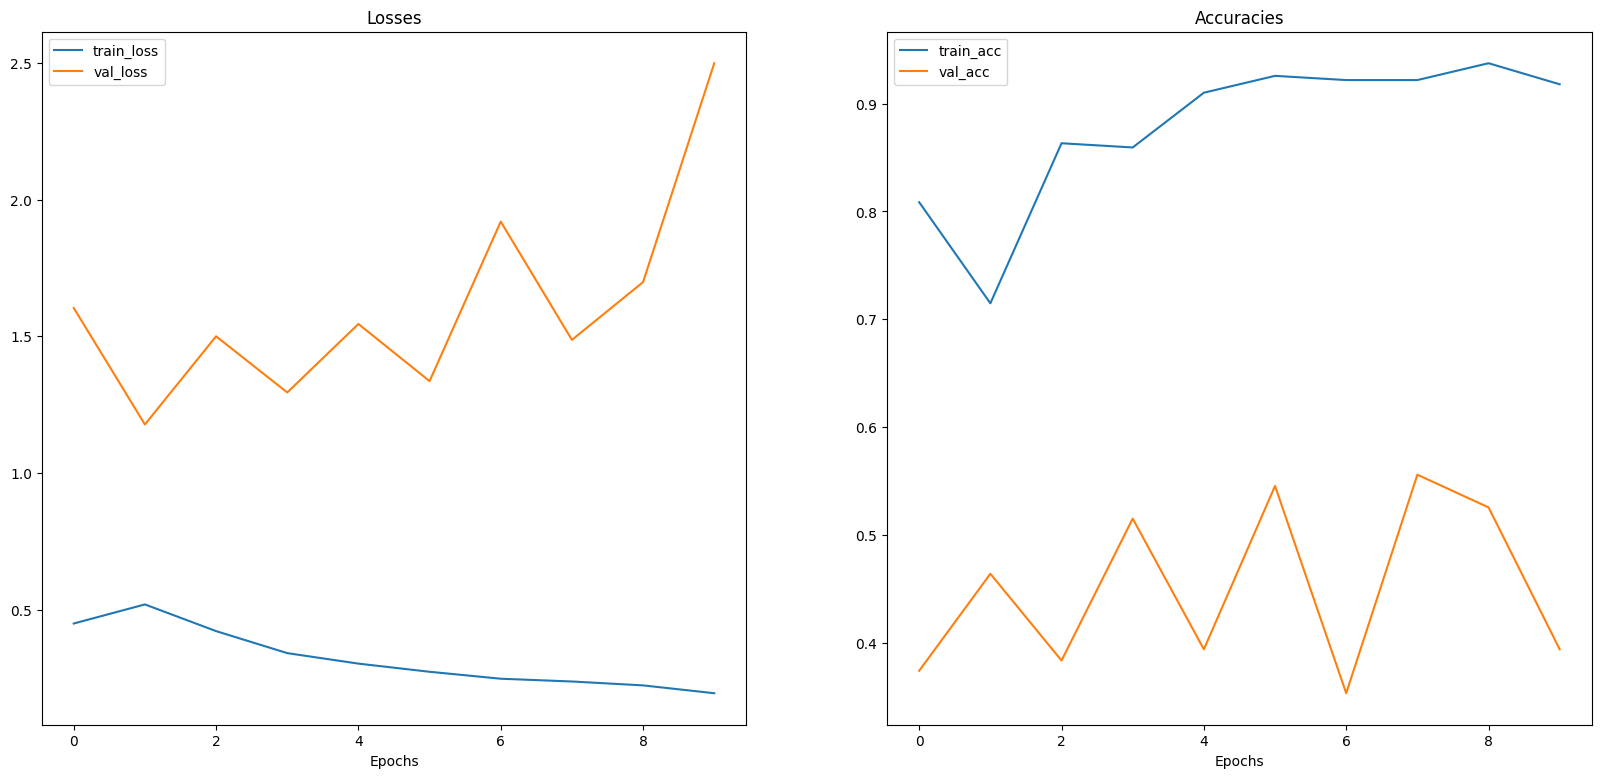

In [60]:
def plot_loss_curve(results:Dict[str,List[float]]):

    loss=results["train_losses"]
    val_loss=results["val_losses"]

    acc=results["train_accuracies"]
    val_acc=results["val_accuracies"]

    epochs=range(len(results["train_losses"]))

    plt.figure(figsize=(20,9))

    plt.subplot(1,2,1)
    plt.plot(epochs,loss,label="train_loss")
    plt.plot(epochs,val_loss,label="val_loss")
    plt.title("Losses")
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs,acc,label="train_acc")
    plt.plot(epochs,val_acc,label="val_acc")
    plt.title("Accuracies")
    plt.xlabel('Epochs')
    plt.legend()


plot_loss_curve(results=model0_results)




# Model1: TinyVGG with Data Augmentation


## build augmented transform for training


In [61]:
train_trivelAug_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

#testing transform is same as model0's


In [63]:
train_aug_dataset=datasets.ImageFolder(root=train_pth,transform=train_trivelAug_transform)

test_dataset_simple=datasets.ImageFolder(root=test_pth,transform=simple_transform)

import os
from torch.utils.data import DataLoader
BATCH_SIZE=32
NUM_WORKER=os.cpu_count()

train_aug_dataloader=DataLoader(train_aug_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKER)

test_simple_dataloader=DataLoader(test_dataset_simple,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKER)

train_aug_dataloader,test_simple_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fd9f395ef10>,
 <torch.utils.data.dataloader.DataLoader at 0x7fd9f3c131d0>)

# Build new models and train

In [64]:
torch.manual_seed(seed=42)

model1=TinyVGG(input_features=3,
               hidden_features=10,
               output_features=len(train_aug_dataset.classes)).to(device)



In [66]:
torch.manual_seed(seed=42)
torch.cuda.manual_seed(seed=42)

NUM_EPOCHS=10

loss_fn=nn.CrossEntropyLoss()

optimizer= torch.optim.Adam(params=model1.parameters(),lr=0.001)

from timeit import default_timer as timer

start_timer=timer()
aug_results=train(model=model1,
                  train_dataloader=train_aug_dataloader,
                  test_dataloader=test_simple_dataloader,
                  optimizer=optimizer,
                  loss_fun=loss_fn,
                  epochs=NUM_EPOCHS)

end_timer=timer()

print(f'the training takes {end_timer-start_timer:.3f} seconds')

 10%|█         | 1/10 [00:02<00:20,  2.32s/it]

Epoch 0|Train_loss:1.1017|Train Accuracy: 0.4219Val_loss:1.1065|Val Accuracy: 0.2604


 20%|██        | 2/10 [00:04<00:17,  2.21s/it]

Epoch 1|Train_loss:1.0879|Train Accuracy: 0.4258Val_loss:1.1134|Val Accuracy: 0.2604


 30%|███       | 3/10 [00:06<00:15,  2.18s/it]

...

Epoch 7|Train_loss:1.0956|Train Accuracy: 0.2812Val_loss:1.1458|Val Accuracy: 0.1979


 90%|█████████ | 9/10 [00:20<00:02,  2.25s/it]

Epoch 8|Train_loss:1.1197|Train Accuracy: 0.2930Val_loss:1.1464|Val Accuracy: 0.2083


100%|██████████| 10/10 [00:22<00:00,  2.26s/it]

Epoch 9|Train_loss:1.0945|Train Accuracy: 0.3750Val_loss:1.1188|Val Accuracy: 0.2604
the training takes 22.639 seconds


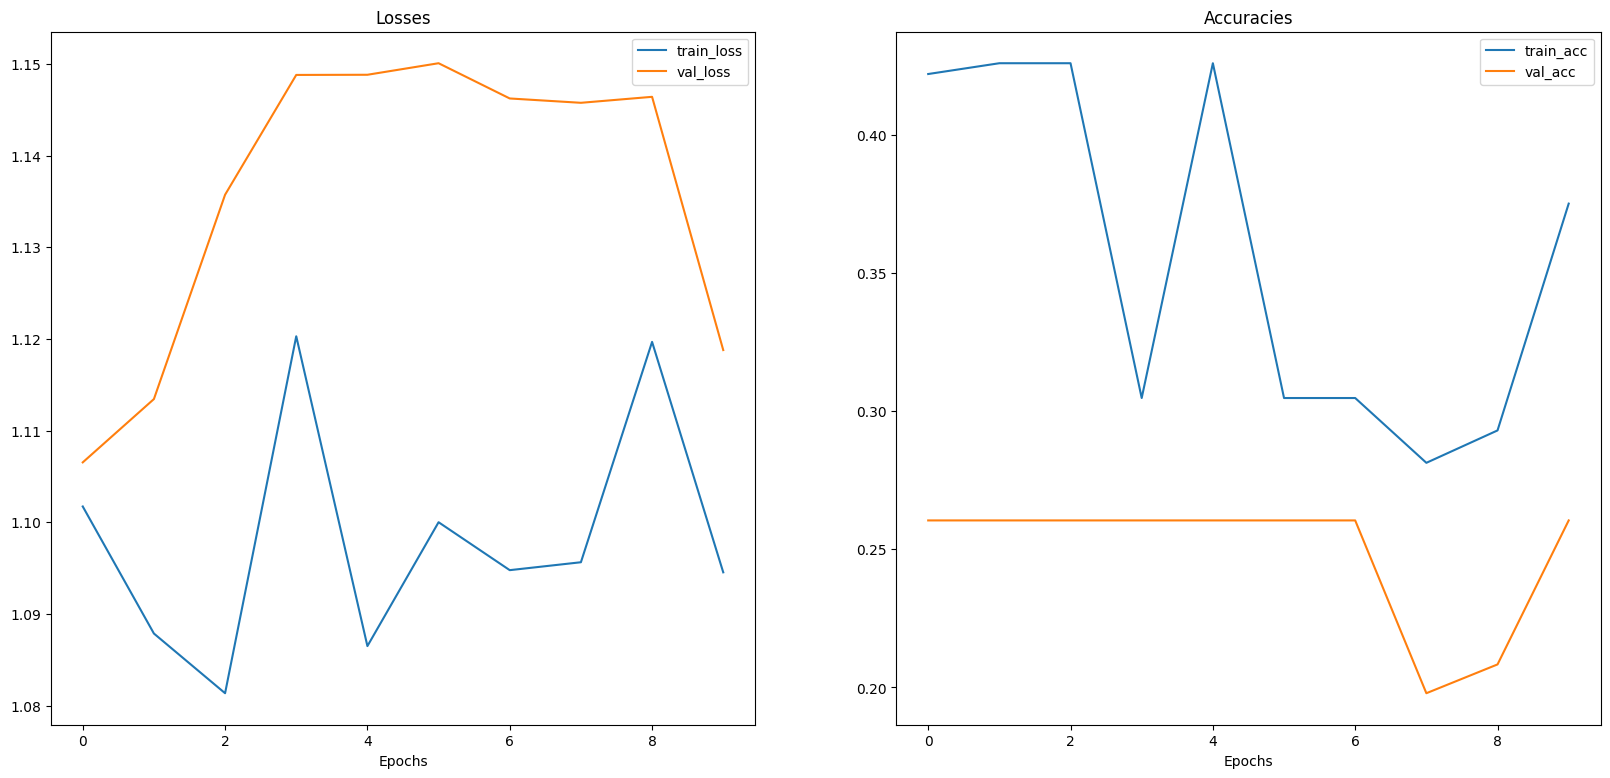

In [67]:
plot_loss_curve(aug_results)

# Compare two models

In [68]:
import pandas as pd


In [70]:
model0_pd=pd.DataFrame(data=model0_results)
model1_pd=pd.DataFrame(data=aug_results)

model0_pd
model1_pd


,train_losses,train_accuracies,val_losses,val_accuracies
0,1.101732,0.421875,1.106542,0.260417
1,1.087873,0.425781,1.113449,0.260417
2,1.081362,0.425781,1.135737,0.260417
3,1.120297,0.304688,1.148805,0.260417
4,1.086503,0.425781,1.148823,0.260417
5,1.100014,0.304688,1.150082,0.260417
6,1.094786,0.304688,1.146238,0.260417
7,1.095648,0.281250,1.145765,0.197917
8,1.119686,0.292969,1.146416,0.208333
9,1.094548,0.375000,1.118792,0.260417


# plot the difference between 2 results

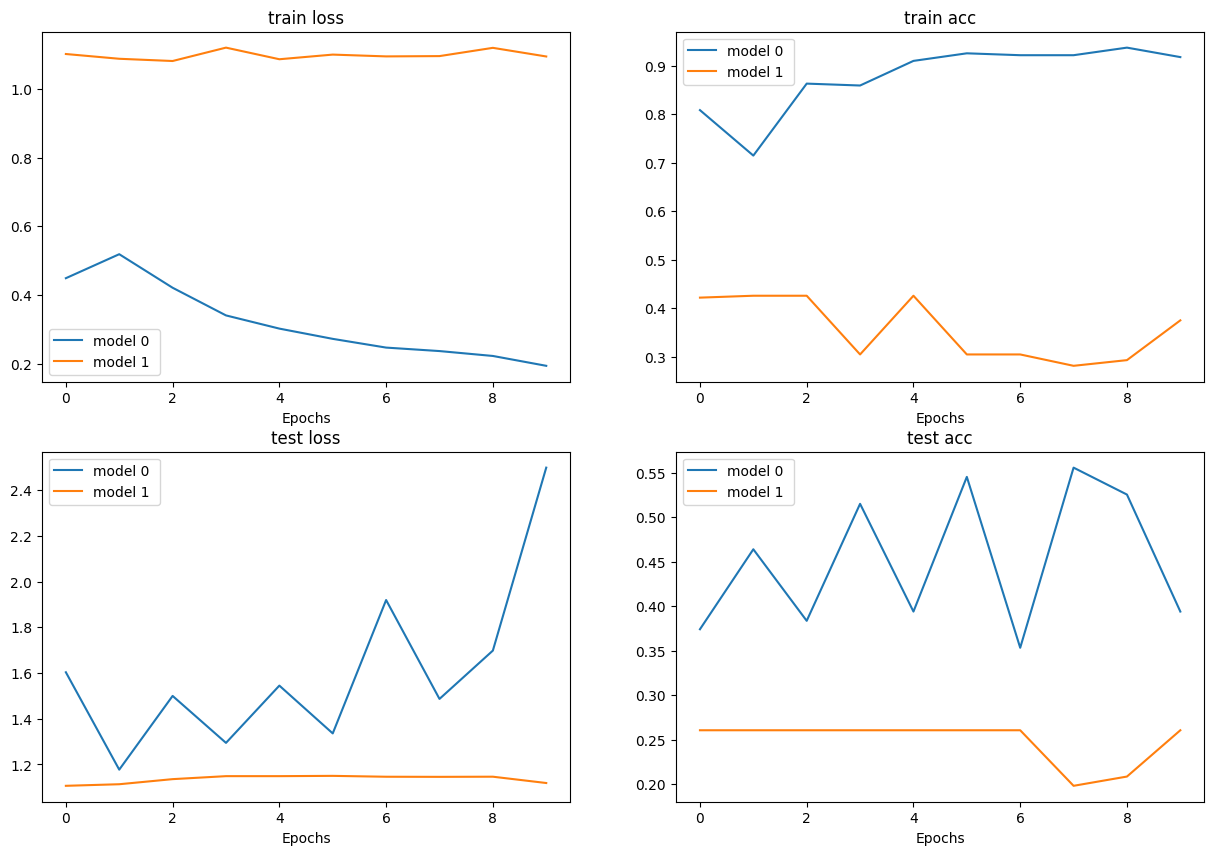

In [72]:
plt.figure(figsize=(15,10))

epochs=range(len(model0_pd))

plt.subplot(2,2,1)
plt.plot(epochs,model0_pd['train_losses'],label="model 0 ")
plt.plot(epochs,model1_pd['train_losses'],label="model 1 ")
plt.title("train loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs,model0_pd['train_accuracies'],label="model 0 ")
plt.plot(epochs,model1_pd['train_accuracies'],label="model 1 ")
plt.title("train acc")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs,model0_pd['val_losses'],label="model 0 ")
plt.plot(epochs,model1_pd['val_losses'],label="model 1 ")
plt.title("test loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs,model0_pd['val_accuracies'],label="model 0 ")
plt.plot(epochs,model1_pd['val_accuracies'],label="model 1 ")
plt.title("test acc")
plt.xlabel("Epochs")
plt.legend()



# Make prediction on a custom data


In [81]:
import requests

custom_image_path= data_path / "pizza_dad.jpeg"

url="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg"

if not custom_image_path.is_file():
    with open(custom_image_path,'wb') as f:
        request=requests.get(url)
        print(f'Downloading custom image {custom_image_path}...')
        f.write(request.content)

else:
    print(f'{custom_image_path} is already exist')




In [82]:
print(custom_image_path)
print("File size:", os.path.getsize(custom_image_path))

/content/sanple_data/food_data/pizza_dad.jpeg
File size: 2874848


# Load the custom image

In [83]:
import torchvision
custom_image_units8=torchvision.io.read_image(custom_image_path)

print(f'Custom image tensor:\n{custom_image_units8}')
print(f'Custom image shape:\n{custom_image_units8.shape}')
print(f'Custom image dtype:\n{custom_image_units8.dtype}')


Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)
Custom image shape:
torch.Size([3, 4032, 3024])
Custom image dtype

### **for now the image pixel value in [0,255],dtype:uint8, mut the model takes tensor of dtype: float32 with the value between [0,1]. Thus the tranformation is necessary ,otherwise there will be runtime error**

In [85]:
custom_image=torchvision.io.read_image(custom_image_path).type(torch.float32)

custom_image= custom_image / 255

print(f'Custom image tensor:\n{custom_image}')
print(f'Custom image shape:\n{custom_image.shape}')
print(f'Custom image dtype:\n{custom_image.dtype}')

Custom image tensor:
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..

# Prediction

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

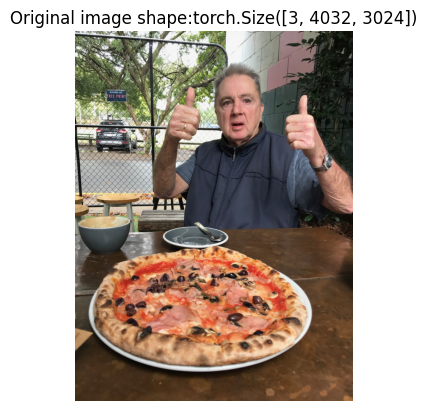

In [86]:
plt.imshow(custom_image.permute(1,2,0))

plt.title(f'Original image shape:{custom_image.shape}')

plt.axis(False)


# Transform custom image

In [87]:
custom_transformation=transforms.Compose([
    transforms.Resize(size=(64,64)),

])

custom_transed_img=custom_transformation(custom_image)
print(f'Transformed shape:{custom_transed_img.shape}')

Transformed shape:torch.Size([3, 64, 64])


In [88]:
model1.eval()

custom_transed_with_batchSize_img=custom_transed_img.unsqueeze(dim=0)

print(f'custom transed img shape:{custom_transed_img.shape}')
print(f'custom transed img with batchSize shape:{custom_transed_with_batchSize_img.shape}')


with torch.inference_mode():
    custom_pred=model1(custom_transed_with_batchSize_img.to(device))

custom transed img shape:torch.Size([3, 64, 64])
custom transed img with batchSize shape:torch.Size([1, 3, 64, 64])


In [90]:
print(f'predicted logits: {custom_pred}')

custom_pred_pob=torch.softmax(custom_pred,dim=1)
print(f'predicted logits probabilities: {custom_pred_pob}')

custom_pred_label=torch.argmax(custom_pred_pob,dim=1)
print(f'predicted label: {custom_pred_label}')

custom_pred_class=class_names[custom_pred_label.cpu()]
custom_pred_class

predicted logits: tensor([[ 0.0209,  0.0117, -0.0827]])
predicted logits probabilities: tensor([[0.3457, 0.3425, 0.3117]])
predicted label: tensor([0])


'pizza'

# Putting predction process into one function

In [93]:
def pred_custom_image(model:nn.Module,
                      image_path:str,
                      class_names:List[str]=None,
                      transform=None,
                      device:torch.device = device):

    #1.load the image and do the regulation and dtype transformation

    target_image=torchvision.io.read_image(path=image_path).type(torch.float32)
    target_image= target_image / 255

    #2. transform if necessary

    if transform is not None:
        target_image=transform(target_image)

    model.to(device)

    model.eval()

    with torch.inference_mode():
       #add batch size dim
        target_image=target_image.unsqueeze(0)

        #make prediction
        pred_logits=model(target_image) #(batch,C,H,W)

        pred_prob=torch.softmax(pred_logits,dim=1) #[[0.0a,0.0b,..]]

        pred_label=torch.argmax(pred_prob,dim=1)

        plt.imshow(target_image.squeeze(0).permute(1,2,0))

        if class_names is not None:
            pred_class=class_names[pred_label.cpu()]
            title=f'pred class is {pred_class}'
        else:
            title=f'pred label is {pred_label}'
        plt.title(title)
        plt.axis(False)



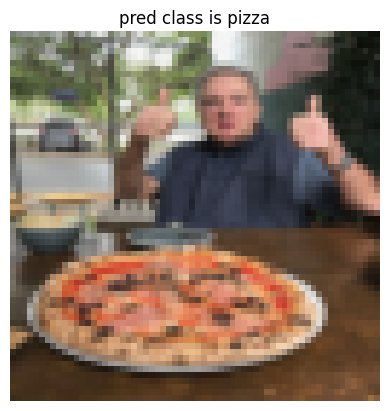

In [94]:
pred_custom_image(model=model1,
                  image_path=custom_image_path,
                  class_names=class_names,
                  transform=custom_transformation,
                  device=device)